## Part 3: Structure Prediction & Visualization

Reproduces **Figure f** from the Nature paper.  
We fold two peptide-receptor complexes for PDB entry **6VME**:
- **Blue** — true test peptide  
- **Red** — PepMLM-generated peptide  
- **Gray** — receptor (shared)

Tool: ESMFold (local, via HuggingFace transformers) → `.pdb` → py3Dmol

### 3.1 — Imports

In [18]:
import pandas as pd
import torch
import py3Dmol
from transformers import AutoTokenizer, AutoModelForMaskedLM, EsmForProteinFolding

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### 3.2 — Load Target Entry (6VME)

In [19]:
test_df = pd.read_csv("../data/pepnn_test_dataset.csv")
entry = test_df[test_df["PDB"] == "6VME"].iloc[0]

RECEPTOR = entry["Receptor Sequence"]
TRUE_PEP = entry["Sequence"]
PEP_LEN  = len(TRUE_PEP)

print(f"PDB         : 6VME")
print(f"Receptor    : {RECEPTOR}")
print(f"True peptide: {TRUE_PEP}  (len={PEP_LEN})")
print(f"Total length: {len(RECEPTOR) + PEP_LEN} aa")

PDB         : 6VME
Receptor    : QSENNDIDEVIIPTAPLYKQILNLYAEENAIEDTIFYLGEALRRGVIDLDVFLKHVRLLSRKQFQLRALMQKARKTAGLSD
True peptide: NASSLYGISAMDGVPFTLH  (len=19)
Total length: 100 aa


### 3.3 — Generate Peptide with PepMLM

In [20]:
PEP_MODEL     = "TianlaiChen/PepMLM-650M"
pep_tokenizer = AutoTokenizer.from_pretrained(PEP_MODEL)
pep_model     = AutoModelForMaskedLM.from_pretrained(PEP_MODEL).to(device)
pep_model.eval()

def generate_peptide(receptor_seq: str, pep_len: int) -> str:
    masked_input = receptor_seq + pep_tokenizer.mask_token * pep_len
    inputs = pep_tokenizer(masked_input, return_tensors="pt",
                           truncation=True, max_length=512).to(device)
    mask_positions = (inputs["input_ids"] == pep_tokenizer.mask_token_id).nonzero(as_tuple=True)[1]
    with torch.no_grad():
        logits = pep_model(**inputs).logits
    predicted_ids = logits[0, mask_positions].argmax(dim=-1)
    return pep_tokenizer.decode(predicted_ids, skip_special_tokens=True).replace(" ", "")

GEN_PEP = generate_peptide(RECEPTOR, PEP_LEN)
print(f"Generated peptide: {GEN_PEP}")
print(f"True peptide     : {TRUE_PEP}")

Loading weights: 100%|██████████| 540/540 [00:00<00:00, 53577.24it/s]


Generated peptide: NASSLYGISSMDVVVFSAH
True peptide     : NASSLYGISAMDGVPFTLH


### 3.4 — Load ESMFold & Fold Both Complexes

ESMFold runs locally — no API or token needed. First download is ~2.7 GB.  
For a 100 aa sequence, folding takes ~1-3 min on CPU.

In [21]:
import time

print("Step 1/4: Loading ESMFold tokenizer...")
fold_tokenizer = AutoTokenizer.from_pretrained("facebook/esmfold_v1")
print("Step 2/4: Loading ESMFold model (~2.7 GB, may take a few minutes)...")
fold_model = EsmForProteinFolding.from_pretrained("facebook/esmfold_v1",
                                                   low_cpu_mem_usage=True)
fold_model = fold_model.to(device)
fold_model.eval()
print("ESMFold loaded.")

def fold_sequence(sequence: str) -> str:
    inputs = fold_tokenizer(sequence, return_tensors="pt",
                            add_special_tokens=False).to(device)
    with torch.no_grad():
        output = fold_model(**inputs)
    return fold_model.output_to_pdb(output)[0]

print("Step 3/4: Folding true complex...")
t0 = time.time()
pdb_true = fold_sequence(RECEPTOR + TRUE_PEP)
print(f"Done in {time.time()-t0:.1f}s")

print("Step 4/4: Folding generated complex...")
t0 = time.time()
pdb_gen = fold_sequence(RECEPTOR + GEN_PEP)
print(f"Done in {time.time()-t0:.1f}s")

Step 1/4: Loading ESMFold tokenizer...
Step 2/4: Loading ESMFold model (~2.7 GB, may take a few minutes)...


Loading weights: 100%|██████████| 4498/4498 [00:46<00:00, 96.87it/s]  
[transformers] EsmForProteinFolding LOAD REPORT from: facebook/esmfold_v1
Key                                | Status  | 
-----------------------------------+---------+-
esm.contact_head.regression.weight | MISSING | 
esm.contact_head.regression.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESMFold loaded.
Step 3/4: Folding true complex...
Done in 217.9s
Step 4/4: Folding generated complex...
Done in 206.8s


### 3.5 — Save PDB Files & Download Structure Images

PDB files saved.


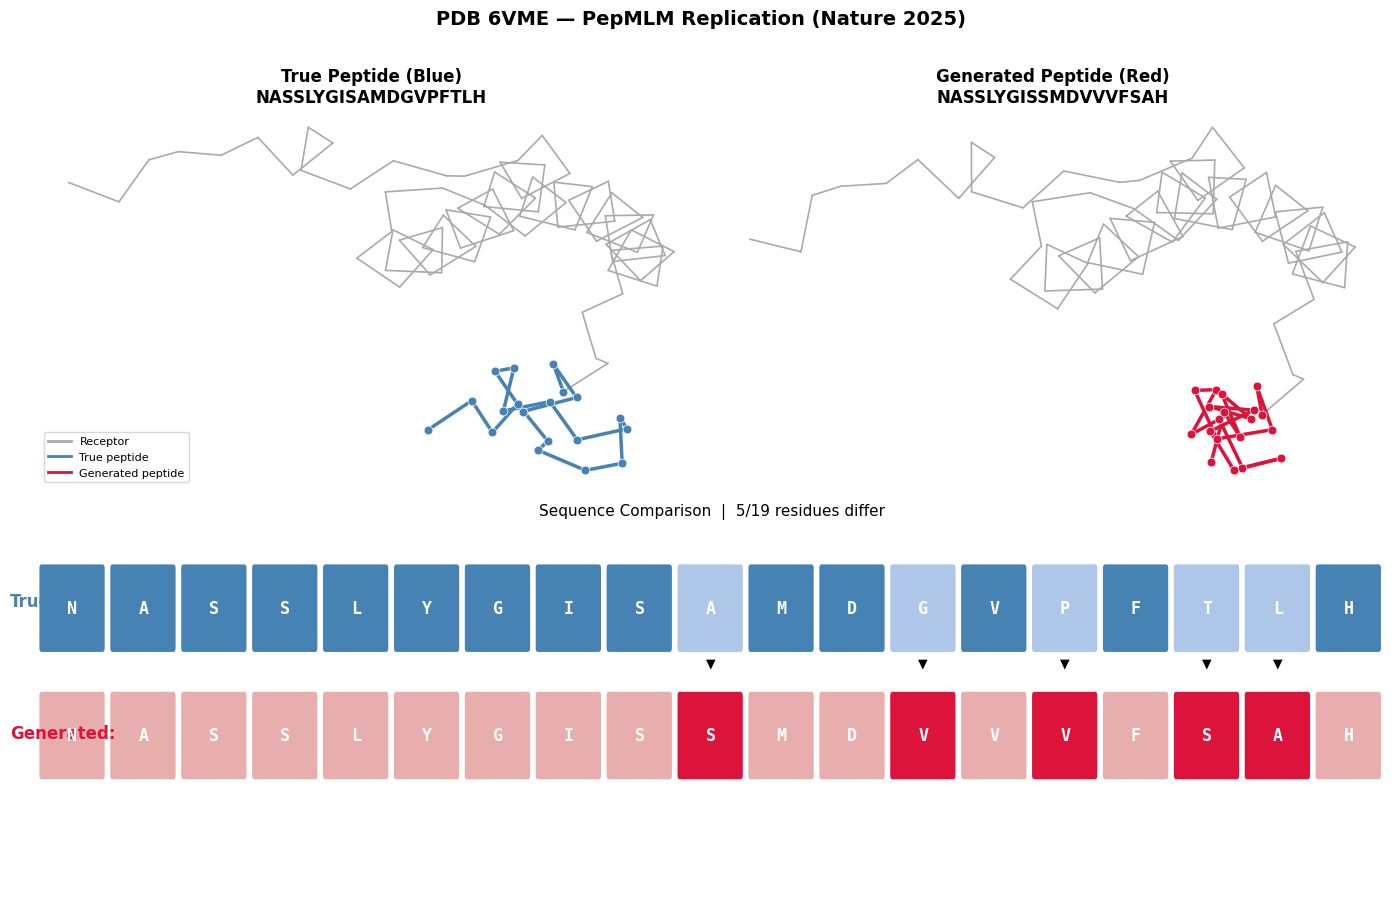

Saved: ../data/structures/6VME_comparison.jpg


In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

out_dir = "../data/structures"
os.makedirs(out_dir, exist_ok=True)

# Save PDB files
with open(os.path.join(out_dir, "6VME_true_peptide.pdb"), "w") as f:
    f.write(pdb_true)
with open(os.path.join(out_dir, "6VME_generated_peptide.pdb"), "w") as f:
    f.write(pdb_gen)
print("PDB files saved.")

# --- Parse CA atoms from a PDB string ---
def parse_ca(pdb_str):
    coords, resnums = [], []
    for line in pdb_str.splitlines():
        if line[:4] == "ATOM" and line[12:16].strip() == "CA":
            x = float(line[30:38])
            y = float(line[38:46])
            resnums.append(int(line[22:26]))
            coords.append((x, y))
    return np.array(coords), resnums

# --- Draw 2D backbone on an axis ---
def draw_backbone(ax, pdb_str, receptor_len, peptide_color, title):
    coords, resnums = parse_ca(pdb_str)
    if len(coords) == 0:
        ax.text(0.5, 0.5, 'No CA atoms found', ha='center', transform=ax.transAxes)
        return
    # Normalize to [0,1]
    coords -= coords.min(axis=0)
    coords /= coords.max(axis=0).clip(min=1e-6)
    for i in range(len(coords) - 1):
        is_pep = resnums[i] > receptor_len
        color  = peptide_color if is_pep else "#aaaaaa"
        lw     = 2.5 if is_pep else 1.2
        ax.plot(coords[i:i+2, 0], coords[i:i+2, 1],
                color=color, lw=lw, solid_capstyle='round')
    # Highlight peptide residues as dots
    for i, rn in enumerate(resnums):
        if rn > receptor_len:
            ax.scatter(coords[i, 0], coords[i, 1],
                       color=peptide_color, s=40, zorder=5, edgecolors='white', lw=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_facecolor('#f8f8f8')
    ax.axis('off')

# --- Build figure ---
fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor('white')

# Row 1: 2D backbone plots
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
draw_backbone(ax1, pdb_true, len(RECEPTOR), 'steelblue',
              f'True Peptide (Blue)\n{TRUE_PEP}')
draw_backbone(ax2, pdb_gen,  len(RECEPTOR), 'crimson',
              f'Generated Peptide (Red)\n{GEN_PEP}')

legend_els = [
    Line2D([0], [0], color='#aaaaaa',  lw=2, label='Receptor'),
    Line2D([0], [0], color='steelblue', lw=2, label='True peptide'),
    Line2D([0], [0], color='crimson',   lw=2, label='Generated peptide'),
]
ax1.legend(handles=legend_els, loc='lower left', fontsize=8)

# Row 2: Sequence comparison array
ax3 = fig.add_subplot(2, 1, 2)
ax3.set_xlim(0, len(TRUE_PEP))
ax3.set_ylim(0, 4)
ax3.axis('off')

ax3.text(-0.4, 3.2, 'True:', fontsize=12, fontweight='bold',
         color='steelblue', va='center')
ax3.text(-0.4, 1.8, 'Generated:', fontsize=12, fontweight='bold',
         color='crimson', va='center')

for i, (t, g) in enumerate(zip(TRUE_PEP, GEN_PEP)):
    match = (t == g)
    ax3.add_patch(FancyBboxPatch((i+0.05, 2.7), 0.85, 0.85,
        boxstyle='round,pad=0.05',
        facecolor='steelblue' if match else '#aec6e8',
        edgecolor='white', lw=1.5))
    ax3.text(i+0.48, 3.13, t, ha='center', va='center',
             fontsize=12, fontweight='bold', color='white', fontfamily='monospace')
    ax3.add_patch(FancyBboxPatch((i+0.05, 1.35), 0.85, 0.85,
        boxstyle='round,pad=0.05',
        facecolor='crimson' if not match else '#e8aeae',
        edgecolor='white', lw=1.5))
    ax3.text(i+0.48, 1.78, g, ha='center', va='center',
             fontsize=12, fontweight='bold', color='white', fontfamily='monospace')
    if not match:
        ax3.text(i+0.48, 2.55, '▼', ha='center', va='center',
                 fontsize=9, color='black')

n_diff = sum(t != g for t, g in zip(TRUE_PEP, GEN_PEP))
ax3.set_title(f'Sequence Comparison  |  {n_diff}/{len(TRUE_PEP)} residues differ',
              fontsize=11, pad=8)

fig.suptitle('PDB 6VME — PepMLM Replication (Nature 2025)',
             fontsize=14, fontweight='bold', y=1.01)

img_path = os.path.join(out_dir, '6VME_comparison.jpg')
plt.tight_layout()
plt.savefig(img_path, dpi=150, bbox_inches='tight', format='jpeg')
plt.show()
print(f'Saved: {img_path}')